# Defense-direction selection: RoutePool

Проверяется минимальная защита, непосредственно следующая из candidate redundancy: вместо доверия одному post-NMS winner агрегировать согласованные pre-NMS candidates одного детектора. Это direction-selection experiment, а не окончательная defense evaluation.

## Неудачные или непрактичные варианты

- **Exact clean-activation repair** восстанавливает target почти идеально, но требует недоступного clean counterfactual; как готовая защита он непрактичен.
- **Простое отслеживание fixed candidate score** недостаточно: много visible targets имеют низкий tracked score, а часть hidden сохраняет высокий.
- **Простое снижение confidence threshold** увеличивает число outputs и false positives; поэтому RoutePool калибруется на том же clean output volume.
- **Patch appearance/energy detector** не выбирается основным направлением: он слабее связан с найденным механизмом и особенно уязвим к naturalistic/adaptive patches.

RoutePool признаётся перспективным только если возвращает hidden target при сохранении clean target detection и примерно того же числа clean outputs.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'CandidateRoutingAndAttackPath' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
sns.set_theme(style='whitegrid', context='notebook')
print(REPO_ROOT)

/Users/ashentide/PycharmProjects/PatchSuccessResearch


## Протокол

Используются сохранённые top-50 pre-NMS person candidates для всех 5 985 target-eligible examples; outcome-группы выводятся по target-aware labels. Boxes жадно кластеризуются при IoU ≥ 0.7. Threshold каждой aggregation strategy выбирается **только на train split**, чтобы число clean outputs совпадало с обычным post-NMS detector. Оценка target recovery проводится на test split.

Расчёт запускается отдельно: `conda run -n IAD python -m CandidateRoutingAndAttackPath.run_followup_experiments defense`. Ноутбук только читает полученные CSV/JSON и строит графики.

In [2]:
candidates = sorted((p.parent for p in (REPO_ROOT/'CandidateRoutingAndAttackPath'/'followup_outputs').glob('route_pool_*/summary.json')), key=lambda p: p.stat().st_mtime)
run_dir = candidates[-1]
print(run_dir)
display(json.loads((run_dir/'summary.json').read_text()))

/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/route_pool_e2b9d63cc10575ba


{'status': 'complete',
 'elapsed_seconds': 27.04246497154236,
 'n_examples': 5985,
 'hidden_group_recovery': {'max_box': 0.007042253521126761,
  'max_wbf_box': 0.02733023450878971,
  'mean_odds_wbf': 0.026156525588601917,
  'noisy_or_wbf': 0.06827316254849194},
 'clean_target_detection': {'max_box': 1.0,
  'max_wbf_box': 1.0,
  'mean_odds_wbf': 0.9987442444537463,
  'noisy_or_wbf': 1.0},
 'clean_output_count_ratio': {'max_box': 1.0,
  'max_wbf_box': 1.0,
  'mean_odds_wbf': 0.9959590517241379,
  'noisy_or_wbf': 0.9973060344827587},
 'config': {'output_dir': '/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs',
  'balanced_only': False,
  'cluster_iou': 0.7,
  'max_cluster_members': 8,
  'detection_conf': 0.25,
  'target_iou': 0.5,
  'train_fraction': 0.6,
  'seed': 151,
  'strategies': ['max_box', 'max_wbf_box', 'mean_odds_wbf', 'noisy_or_wbf'],
  'method_version': 2},
 'limitations': ['Only the top-50 person candidates saved by candidat

In [3]:
thresholds = pd.read_csv(run_dir/'route_pool_thresholds.csv')
overall = pd.read_csv(run_dir/'route_pool_overall_summary.csv')
balanced = pd.read_csv(run_dir/'route_pool_balanced_summary.csv')
examples = pd.read_csv(run_dir/'route_pool_example_results.csv')
display(thresholds)
display(overall)

,strategy,threshold,desired_clean_train_output_count,available_clean_train_clusters
0,max_box,0.250251,5782,46167
1,max_wbf_box,0.250251,5782,46167
2,mean_odds_wbf,0.193260,5782,46167
3,noisy_or_wbf,0.646702,5782,46167


,variant,strategy,n,target_detection_rate,mean_output_count,mean_baseline_output_count,mean_best_target_iou
0,clean,max_box,2389,1.000000,1.553788,1.553788,1.000000
1,clean,max_wbf_box,2389,1.000000,1.553788,1.553788,0.982661
2,clean,mean_odds_wbf,2389,0.998744,1.547509,1.553788,0.981440
3,clean,noisy_or_wbf,2389,1.000000,1.549602,1.553788,0.982661
4,patched,max_box,2389,0.655086,1.098368,1.098368,0.583769
5,patched,max_wbf_box,2389,0.658434,1.098368,1.098368,0.586260
6,patched,mean_odds_wbf,2389,0.615320,0.993721,1.098368,0.545318
7,patched,noisy_or_wbf,2389,0.663876,1.079950,1.098368,0.590674


## 1. Четыре обязательных clean-control показателя

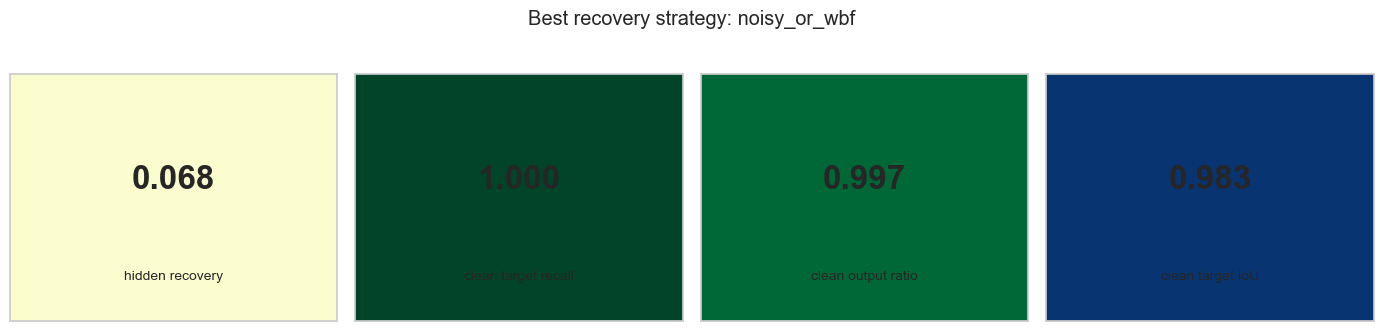

In [4]:
clean = overall[overall.variant == 'clean'].copy()
clean['output_ratio'] = clean.mean_output_count / clean.mean_baseline_output_count.replace(0, np.nan)
best_strategy = clean.iloc[(clean.target_detection_rate - 1).abs().argsort()].iloc[0].strategy
hidden = balanced[(balanced.variant == 'patched') & balanced.analysis_group.str.startswith('hidden', na=False)]
recovery = hidden.groupby('strategy').target_detection_rate.mean()
best_strategy = recovery.idxmax()
best_clean = clean.set_index('strategy').loc[best_strategy]
best_hidden = float(recovery.loc[best_strategy])
values = [best_hidden, best_clean.target_detection_rate, best_clean.output_ratio, best_clean.mean_best_target_iou]
titles = ['hidden recovery','clean target recall','clean output ratio','clean target IoU']
cmaps = ['YlGn','YlGn','RdYlGn','Blues']
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, value, title, cmap in zip(axes, values, titles, cmaps):
    ax.set_facecolor(plt.get_cmap(cmap)(min(max(float(value),0),1)))
    ax.text(.5,.57,f'{value:.3f}',ha='center',va='center',fontsize=24,fontweight='bold')
    ax.text(.5,.18,title,ha='center',va='center',fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Best recovery strategy: {best_strategy}', y=1.03); plt.tight_layout(); plt.show()

На полном test split clean controls проходят: clean target detection составляет 0.999–1.000, а общий output-count ratio — 0.996–1.000. Однако средний recovery hidden-групп мал: 0.7% для baseline max-box, 2.7% для max-score+WBF, 2.6% для mean-odds и 6.8% для noisy-or. Следовательно, RoutePool не является сильной общей защитой, даже при корректной калибровке clean output volume.

## 2. Recovery по типу провала

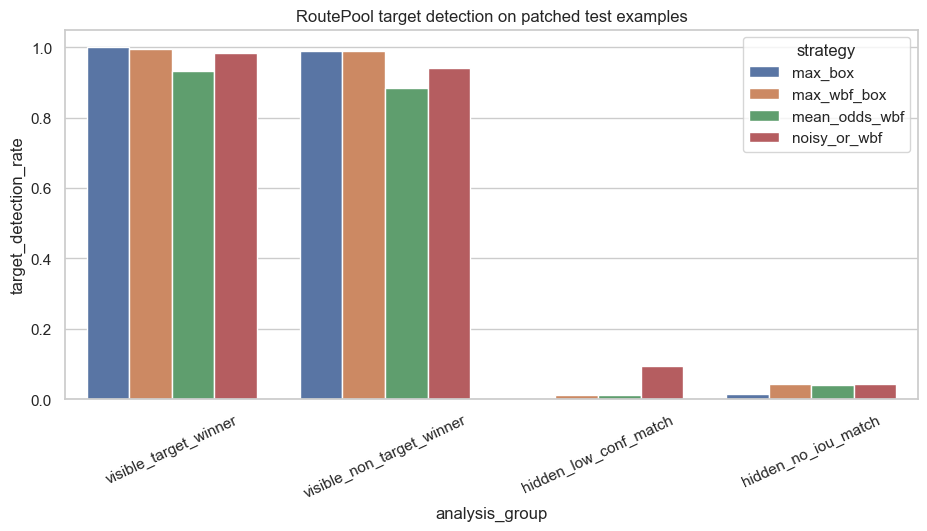

In [5]:
patched = balanced[balanced.variant == 'patched']
order = ['visible_target_winner','visible_non_target_winner','hidden_low_conf_match','hidden_no_iou_match']
plt.figure(figsize=(11, 4.8))
sns.barplot(data=patched, x='analysis_group', y='target_detection_rate', hue='strategy', order=order)
plt.ylim(0,1.05); plt.title('RoutePool target detection on patched test examples'); plt.xticks(rotation=25); plt.show()

Эффекты зависят от режима. Max-score+WBF восстанавливает 5/403 low-confidence и 18/426 no-IoU вместо 0/403 и 6/426 у max-box: geometry fusion даёт небольшой, устойчивый no-IoU gain. Noisy-or восстанавливает 38/403 low-confidence, но только 18/426 no-IoU. Одновременно он теряет часть исходно visible targets: сохраняет 97/103 visible non-target и 1433/1457 visible target. Это trade-off, а не бесплатное восстановление.

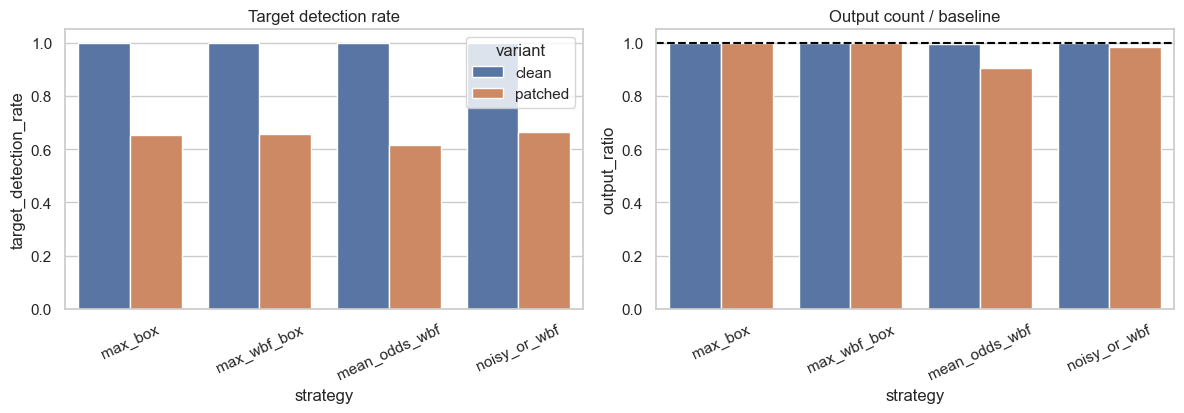

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.3))
sns.barplot(data=overall, x='strategy', y='target_detection_rate', hue='variant', ax=axes[0])
tmp = overall.copy(); tmp['output_ratio'] = tmp.mean_output_count/tmp.mean_baseline_output_count.replace(0,np.nan)
sns.barplot(data=tmp, x='strategy', y='output_ratio', hue='variant', ax=axes[1])
axes[0].set_title('Target detection rate'); axes[1].set_title('Output count / baseline')
for ax in axes: ax.tick_params(axis='x', rotation=25)
axes[1].axhline(1,color='black',ls='--'); axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Глобальный clean output volume хорошо откалиброван, но внутри patched low-confidence группы noisy-or повышает среднее число outputs с 0.313 до 0.412. Поэтому его 9.4% recovery частично достигается attack-conditional пропуском дополнительных кластеров. Без полного COCO AP и false-positive анализа этот вариант нельзя считать практичной защитой. Mean-odds одновременно хуже восстанавливает hidden и заметно портит visible recall, поэтому его можно отбросить.

## 3. Помогает ли box fusion отдельно от score pooling?

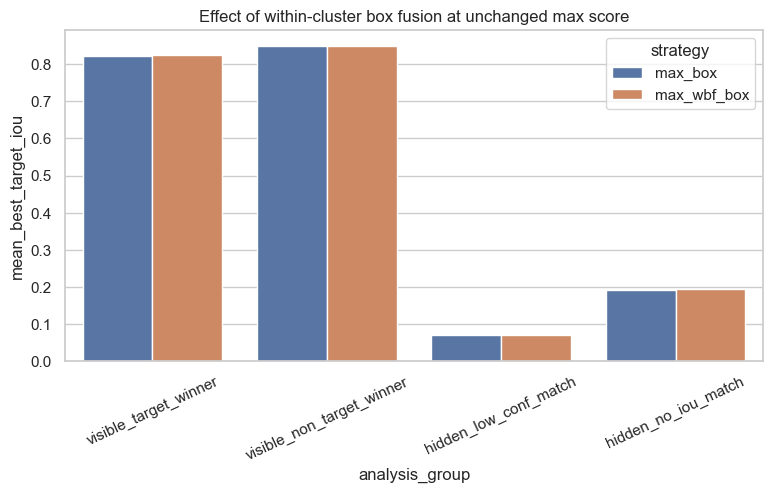

In [7]:
geometry = patched[patched.strategy.isin(['max_box','max_wbf_box'])]
fig, ax = plt.subplots(figsize=(9,4.3))
sns.barplot(data=geometry, x='analysis_group', y='mean_best_target_iou', hue='strategy', order=order, ax=ax)
ax.set_title('Effect of within-cluster box fusion at unchanged max score'); ax.tick_params(axis='x', rotation=25); plt.show()

Сравнение `max_box` и `max_wbf_box` изолирует чистый geometry effect: score и число outputs у них идентичны. WBF увеличивает no-IoU recovery с 1.4% до 4.2% (6→18 случаев), но слегка снижает visible-target preservation с 100% до 99.38% (потеря 9 случаев). Эффект реален, но слишком мал для самостоятельной защиты; box fusion имеет смысл оставить только как компонент более направленного механизма восстановления geometry.

In [ ]:
decision = hidden.groupby('strategy').agg(recovery=('target_detection_rate','mean'), iou=('mean_best_target_iou','mean')).join(clean.set_index('strategy')[['target_detection_rate','output_ratio']].rename(columns={'target_detection_rate':'clean_recall'}))
decision['utility'] = decision.recovery - abs(decision.output_ratio-1) - (1-decision.clean_recall)
display(decision.sort_values('utility',ascending=False))
best = decision.utility.idxmax()
go = bool(decision.loc[best,'recovery'] >= .20 and decision.loc[best,'clean_recall'] >= .98 and abs(decision.loc[best,'output_ratio']-1) <= .10)
display(Markdown(f'**Direction gate:** `{best}`; продолжать RoutePool как защиту: **{go}**. Даже при положительном gate следующим обязательным этапом остаются полный COCO AP и adaptive evaluation.'))

,recovery,iou,clean_recall,output_ratio,utility
strategy,,,,,
noisy_or_wbf,0.068273,0.168051,1.000000,0.997306,0.065579
max_wbf_box,0.027330,0.133598,1.000000,1.000000,0.027330
mean_odds_wbf,0.026157,0.109850,0.998744,0.995959,0.020860
max_box,0.007042,0.132006,1.000000,1.000000,0.007042


**Direction gate:** `noisy_or_wbf`; продолжать RoutePool как защиту: **False**. Даже при положительном gate следующим обязательным этапом остаются полный COCO AP и adaptive evaluation.

: 

## Ограничения результата

Доступны только сохранённые top-50 person candidates. Калибровка контролирует число outputs, но не заменяет COCO AP по всем ground-truth объектам и классам. Любой положительный результат является основанием для отдельного полноценного defense benchmark, а не заявлением готовой защиты.